# ROS2 Bag Exploration (`robin_data_01`)

This notebook inspects the bag at:

`/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/robin_data_01`

and builds quick topic-level DataFrames for geometry and welding telemetry.


In [151]:
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore, get_types_from_idl, get_types_from_msg

BAG_PATH = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/robin_data_01')
assert BAG_PATH.exists(), f'Bag path does not exist: {BAG_PATH}'

print('Bag path:', BAG_PATH)


Bag path: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/robin_data_01


In [152]:
metadata_path = BAG_PATH / 'metadata.yaml'
metadata = yaml.safe_load(metadata_path.read_text())
info = metadata.get('rosbag2_bagfile_information', {})

print('storage_identifier:', info.get('storage_identifier'))
print('ros_distro:', info.get('ros_distro'))
print('message_count:', info.get('message_count'))
print('duration_s:', round(info.get('duration', {}).get('nanoseconds', 0) / 1e9, 3))
print('\nTopics:')
for item in info.get('topics_with_message_count', []):
    tm = item.get('topic_metadata', {})
    print(f"- {tm.get('name')} ({tm.get('type')}): {item.get('message_count')} msgs")


storage_identifier: mcap
ros_distro: jazzy
message_count: 68310
duration_s: 2469.795

Topics:
- /robin/weld_dimensions (robin_interfaces/msg/BeadGeometry): 34774 msgs
- /robin/data/progression (robin_interfaces/msg/WeldProgression): 24699 msgs
- /robin/data/is_welding (std_msgs/msg/Bool): 60 msgs
- /robin/data/fronius (robin_interfaces/msg/WelderData): 8716 msgs
- /robin/data/active_bead (robin_interfaces/msg/ActiveBead): 61 msgs


In [153]:
def _extract_msgdef_text(msgdef):
    if msgdef is None:
        return None
    if isinstance(msgdef, str):
        return msgdef
    if isinstance(msgdef, bytes):
        return msgdef.decode('utf-8', errors='ignore')
    if isinstance(msgdef, tuple) and len(msgdef) >= 2:
        payload = msgdef[1]
        if isinstance(payload, str):
            return payload
        if isinstance(payload, bytes):
            return payload.decode('utf-8', errors='ignore')
    return str(msgdef)


def _build_typestore(reader):
    ts = get_typestore(Stores.ROS2_JAZZY)
    for conn in reader.connections:
        msgdef = _extract_msgdef_text(getattr(conn, 'msgdef', None))
        if not msgdef:
            continue
        for parser in (get_types_from_idl, get_types_from_msg):
            try:
                types = parser(msgdef) if parser is get_types_from_idl else parser(msgdef, conn.msgtype)
                ts.register(types)
                break
            except Exception:
                continue
    return ts


In [154]:
geometry_rows = []
fronius_rows = []
progression_rows = []

with Reader(str(BAG_PATH)) as reader:
    typestore = _build_typestore(reader)

    for conn, timestamp_ns, raw in reader.messages():
        msg = typestore.deserialize_cdr(raw, conn.msgtype)

        if conn.topic == '/robin/weld_dimensions':
            geometry_rows.append({
                'timestamp_ns': int(timestamp_ns),
                'bead_id': getattr(msg, 'bead_id', ''),
                'progression': float(getattr(msg, 'progression', np.nan)),
                'height_mm': float(getattr(msg, 'height_mm', np.nan)),
                'width_mm': float(getattr(msg, 'width_mm', np.nan)),
            })

        elif conn.topic == '/robin/data/fronius':
            fronius_rows.append({
                'timestamp_ns': int(timestamp_ns),
                'bead_id': getattr(msg, 'bead_id', ''),
                'progression': float(getattr(msg, 'progression', np.nan)),
                'current': float(getattr(msg, 'current', np.nan)),
                'voltage': float(getattr(msg, 'voltage', np.nan)),
                'wire_feed_speed': float(getattr(msg, 'wire_feed_speed', np.nan)),
                'power': float(getattr(msg, 'power', np.nan)),
            })

        elif conn.topic == '/robin/data/progression':
            p = getattr(msg, 'tcp_position', None)
            progression_rows.append({
                'timestamp_ns': int(timestamp_ns),
                'bead_id': getattr(msg, 'bead_id', ''),
                'progression': float(getattr(msg, 'progression', np.nan)),
                'is_welding': bool(getattr(msg, 'is_welding', False)),
                'x': float(getattr(p, 'x', np.nan)) if p is not None else np.nan,
                'y': float(getattr(p, 'y', np.nan)) if p is not None else np.nan,
                'z': float(getattr(p, 'z', np.nan)) if p is not None else np.nan,
            })

geometry_df = pd.DataFrame(geometry_rows).sort_values('timestamp_ns')
fronius_df = pd.DataFrame(fronius_rows).sort_values('timestamp_ns')
progress_df = pd.DataFrame(progression_rows).sort_values('timestamp_ns')

print('geometry rows:', len(geometry_df))
print('fronius rows :', len(fronius_df))
print('progress rows:', len(progress_df))


geometry rows: 34774
fronius rows : 8716
progress rows: 24699


In [155]:
display(geometry_df.head(5))
display(fronius_df.head(5))
display(progress_df.head(5))


,timestamp_ns,bead_id,progression,height_mm,width_mm
0,1773788009200399375,B001,0.050490,0.578308,4.291553
1,1773788009224788618,B001,0.050490,0.000000,0.000000
2,1773788009250450943,B001,0.050490,0.000000,0.000000
3,1773788009276925850,B001,0.036687,0.000000,0.000000
4,1773788009301520023,B001,0.036687,0.351093,3.722356


,timestamp_ns,bead_id,progression,current,voltage,wire_feed_speed,power
0,1773787957553222099,B001,0.004679,67.400002,14.789189,2.867568,1.001303
1,1773787957653361365,B001,0.005293,63.012501,1.064062,1.986719,0.340296
2,1773787957753292324,B001,0.009741,63.012501,1.064062,1.986719,0.340296
3,1773787957853661751,B001,0.009929,63.012501,1.064062,1.986719,0.340296
4,1773787957953797981,B001,0.013559,67.400002,14.789189,2.867568,1.001303


,timestamp_ns,bead_id,progression,is_welding,x,y,z
0,1773787932758073382,,0.0,False,-0.893300,-0.593047,-0.150180
1,1773787932853020437,,0.0,False,-0.893302,-0.593065,-0.150191
2,1773787932952917166,,0.0,False,-0.893332,-0.593044,-0.150182
3,1773787933052995181,,0.0,False,-0.893296,-0.593095,-0.150177
4,1773787933153460901,,0.0,False,-0.893303,-0.593057,-0.150197


In [156]:
# Merge geometry with Fronius telemetry.
# Primary strategy: align within each bead by nearest progression.
# Fallback: align by raw bag timestamp for legacy bags without bead/progression IDs.
alignment_mode = 'none'

if not geometry_df.empty and not fronius_df.empty:
    geom_merge = geometry_df.copy()
    fron_merge = fronius_df.copy()

    for _df in (geom_merge, fron_merge):
        if 'bead_id' in _df.columns:
            _df['bead_id'] = _df['bead_id'].fillna('').astype(str).str.strip()

    can_use_progression = (
        'progression' in geom_merge.columns and 'progression' in fron_merge.columns
    )

    if can_use_progression:
        geom_valid = geom_merge[
            (geom_merge['bead_id'] != '') & geom_merge['progression'].notna()
        ].copy()
        fron_valid = fron_merge[
            (fron_merge['bead_id'] != '') & fron_merge['progression'].notna()
        ].copy()
        common_beads = sorted(
            set(geom_valid['bead_id']).intersection(set(fron_valid['bead_id']))
        )
    else:
        geom_valid = pd.DataFrame()
        fron_valid = pd.DataFrame()
        common_beads = []

    if common_beads:
        merged_parts = []
        progression_tolerance = 0.01

        for bead in common_beads:
            g_bead = geom_valid[geom_valid['bead_id'] == bead].sort_values(
                ['progression', 'timestamp_ns']
            )
            f_bead = fron_valid[fron_valid['bead_id'] == bead].sort_values(
                ['progression', 'timestamp_ns']
            )
            if g_bead.empty or f_bead.empty:
                continue

            bead_merged = pd.merge_asof(
                g_bead,
                f_bead.drop(columns=['bead_id']),
                on='progression',
                direction='nearest',
                tolerance=progression_tolerance,
                suffixes=('_geom', '_fron'),
            )
            bead_merged['bead_id'] = bead
            merged_parts.append(bead_merged)

        merged = pd.concat(merged_parts, ignore_index=True) if merged_parts else pd.DataFrame()
        alignment_mode = 'bead_id+progression'
    else:
        merged = pd.merge_asof(
            geom_merge.sort_values('timestamp_ns'),
            fron_merge.sort_values('timestamp_ns'),
            on='timestamp_ns',
            direction='nearest',
            tolerance=200_000_000,  # 200 ms
            suffixes=('_geom', '_fron'),
        )
        alignment_mode = 'timestamp'
else:
    merged = pd.DataFrame()

print('alignment mode:', alignment_mode)
print('merged rows:', len(merged))
if not merged.empty:
    summary_cols = [
        col
        for col in [
            'bead_id',
            'progression',
            'progression_geom',
            'progression_fron',
            'timestamp_ns_geom',
            'timestamp_ns_fron',
            'timestamp_ns',
            'height_mm',
            'width_mm',
            'current',
            'voltage',
            'wire_feed_speed',
        ]
        if col in merged.columns
    ]
    display(merged[summary_cols].head(10))



alignment mode: bead_id+progression
merged rows: 34774


,bead_id,progression,timestamp_ns_geom,timestamp_ns_fron,height_mm,width_mm,current,voltage,wire_feed_speed
0,B001,0.004274,1773788009659013199,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
1,B001,0.004274,1773788009684279198,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
2,B001,0.004274,1773788009708353955,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
3,B001,0.004274,1773788009731074296,1773787957553222099,0.340109,2.451902,67.400002,14.789189,2.867568
4,B001,0.004274,1773788009756714954,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
5,B001,0.004520,1773788009563049081,1773787957553222099,0.423950,5.066209,67.400002,14.789189,2.867568
6,B001,0.004520,1773788009587036438,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
7,B001,0.004520,1773788009611725618,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
8,B001,0.004520,1773788009637390938,1773787957553222099,0.000000,0.000000,67.400002,14.789189,2.867568
9,B001,0.007507,1773788009784792867,1773787957653361365,0.388370,2.701906,63.012501,1.064062,1.986719


saved plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/ros2bag_3beads_overview.png


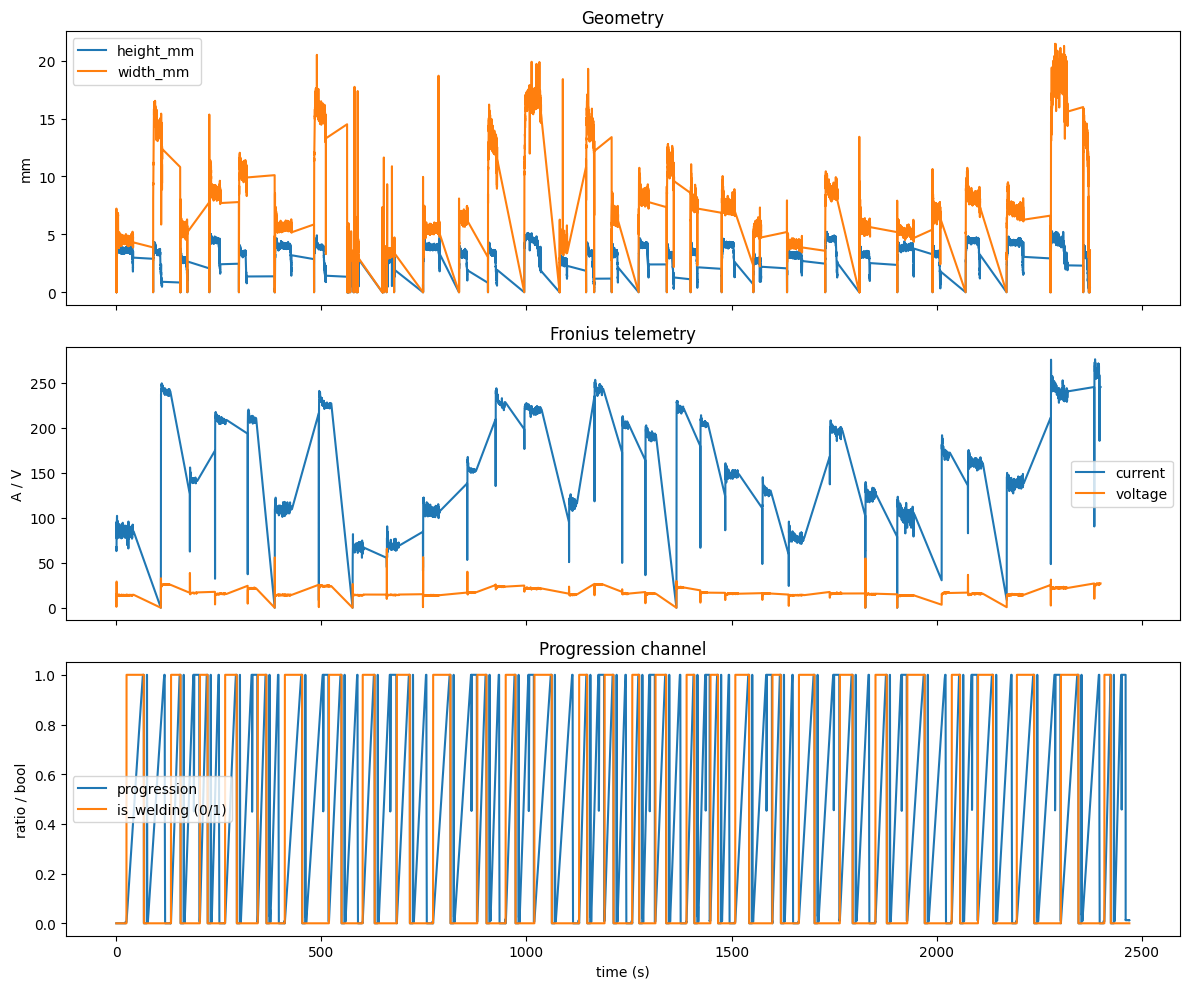

In [157]:
# Quick plots
plot_dir = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks')
plot_dir.mkdir(parents=True, exist_ok=True)
out_png = plot_dir / 'ros2bag_3beads_overview.png'

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

if not geometry_df.empty:
    t = (geometry_df['timestamp_ns'] - geometry_df['timestamp_ns'].min()) / 1e9
    axes[0].plot(t, geometry_df['height_mm'], label='height_mm')
    axes[0].plot(t, geometry_df['width_mm'], label='width_mm')
    axes[0].set_ylabel('mm')
    axes[0].legend()
    axes[0].set_title('Geometry')

if not fronius_df.empty:
    t = (fronius_df['timestamp_ns'] - fronius_df['timestamp_ns'].min()) / 1e9
    axes[1].plot(t, fronius_df['current'], label='current')
    axes[1].plot(t, fronius_df['voltage'], label='voltage')
    axes[1].set_ylabel('A / V')
    axes[1].legend()
    axes[1].set_title('Fronius telemetry')

if not progress_df.empty:
    t = (progress_df['timestamp_ns'] - progress_df['timestamp_ns'].min()) / 1e9
    axes[2].plot(t, progress_df['progression'], label='progression')
    axes[2].plot(t, progress_df['is_welding'].astype(int), label='is_welding (0/1)')
    axes[2].set_ylabel('ratio / bool')
    axes[2].set_xlabel('time (s)')
    axes[2].legend()
    axes[2].set_title('Progression channel')

fig.tight_layout()
fig.savefig(out_png, dpi=150)
print('saved plot:', out_png)


## Bead-Level Exploration

This section derives bead-level summaries:

- number of beads in the run
- average process parameters per bead (`current`, `voltage`, `wire_feed_speed`)
- average geometry per bead (`height_mm`, `width_mm`)


In [158]:
# Normalize bead IDs and enrich geometry with bead labels when missing.
for _df in (geometry_df, fronius_df, progress_df):
    if 'bead_id' in _df.columns:
        _df['bead_id'] = _df['bead_id'].fillna('').astype(str).str.strip()

# Use progression stream to backfill geometry bead_id where geometry has empty IDs.
progress_beads = progress_df[
    (progress_df['bead_id'] != '') & (progress_df['is_welding'] == True)
].copy()
progress_beads = progress_beads.sort_values('timestamp_ns')

geometry_enriched = geometry_df.sort_values('timestamp_ns').copy()
if not progress_beads.empty:
    geom_fill = pd.merge_asof(
        geometry_enriched[['timestamp_ns']],
        progress_beads[['timestamp_ns', 'bead_id']],
        on='timestamp_ns',
        direction='nearest',
        tolerance=500_000_000,  # 500 ms
    )
    missing_mask = geometry_enriched['bead_id'] == ''
    geometry_enriched.loc[missing_mask, 'bead_id'] = geom_fill.loc[missing_mask, 'bead_id'].fillna('')

# Keep geometry rows that look physically meaningful for summary statistics.
geometry_valid = geometry_enriched[
    (geometry_enriched['bead_id'] != '') &
    (geometry_enriched['height_mm'] > 0) &
    (geometry_enriched['width_mm'] > 0)
].copy()

fronius_valid = fronius_df[fronius_df['bead_id'] != ''].copy()

print('beads in fronius:', sorted(fronius_valid['bead_id'].unique().tolist()))
print('beads in geometry_valid:', sorted(geometry_valid['bead_id'].unique().tolist()))
print('n_beads (union):', len(sorted(set(fronius_valid['bead_id']).union(set(geometry_valid['bead_id'])))))


beads in fronius: ['B001', 'B002', 'B003', 'B004', 'B005', 'B006', 'B007', 'B008', 'B009', 'B010', 'B011', 'B012', 'B013', 'B014', 'B015', 'B016', 'B017', 'B018', 'B019', 'B020', 'B021', 'B022', 'B023', 'B024', 'B025', 'B026', 'B027', 'B028', 'B029', 'B030']
beads in geometry_valid: ['B001', 'B002', 'B003', 'B004', 'B005', 'B006', 'B007', 'B008', 'B009', 'B010', 'B011', 'B012', 'B013', 'B014', 'B015', 'B016', 'B017', 'B018', 'B019', 'B020', 'B021', 'B022', 'B023', 'B024', 'B025', 'B026', 'B027', 'B028', 'B029', 'B030']
n_beads (union): 30


In [159]:
# Per-bead process parameters (from Fronius telemetry).
if fronius_valid.empty:
    process_summary = pd.DataFrame()
else:
    process_summary = (
        fronius_valid
        .groupby('bead_id', as_index=False)
        .agg(
            process_samples=('bead_id', 'size'),
            current_mean=('current', 'mean'),
            current_std=('current', 'std'),
            voltage_mean=('voltage', 'mean'),
            voltage_std=('voltage', 'std'),
            wire_feed_speed_mean=('wire_feed_speed', 'mean'),
            wire_feed_speed_std=('wire_feed_speed', 'std'),
            progression_max=('progression', 'max'),
            t_start_ns=('timestamp_ns', 'min'),
            t_end_ns=('timestamp_ns', 'max'),
        )
    )
    process_summary['process_duration_s'] = (
        (process_summary['t_end_ns'] - process_summary['t_start_ns']) / 1e9
    )

display(process_summary)


,bead_id,process_samples,current_mean,current_std,voltage_mean,voltage_std,wire_feed_speed_mean,wire_feed_speed_std,progression_max,t_start_ns,t_end_ns,process_duration_s
0,B001,423,84.996440,5.626735,13.997552,1.541317,2.857861,0.076081,1.0,1773787957553222099,1773787999753252521,42.200030
1,B002,233,238.624020,23.522211,25.379781,2.560554,11.095707,1.001092,1.0,1773788066053117059,1773788089253760371,23.200643
2,B003,188,141.007134,11.280762,17.020014,3.461290,5.592254,0.270671,1.0,1773788136553083853,1773788155253102016,18.700018
3,B004,285,207.395602,15.366035,15.345407,1.033239,8.342854,0.594787,1.0,1773788197953867199,1773788226353047512,28.399180
4,B005,209,208.799652,17.178260,21.349424,1.740848,9.126423,0.820242,1.0,1773788277753868058,1773788298552995165,20.799127
5,B006,423,108.838567,10.779164,14.357706,3.733399,3.717821,0.336633,1.0,1773788343553523121,1773788385755026158,42.201503
6,B007,306,225.708762,18.167955,23.935166,1.959258,10.504031,0.772320,1.0,1773788451153550407,1773788481653563377,30.500013
7,B008,292,66.212407,7.600140,14.107273,1.781267,2.295149,0.031079,1.0,1773788533355134232,1773788562459557602,29.104423
8,B009,317,69.004056,4.765084,14.540563,4.109328,2.363103,0.191611,1.0,1773788616660179289,1773788648253384007,31.593205
9,B010,424,107.489268,8.290539,14.055099,3.696847,3.543818,0.250771,1.0,1773788705056015919,1773788747353162284,42.297146


In [160]:
# Per-bead geometry summary.
if geometry_valid.empty:
    geometry_summary = pd.DataFrame()
else:
    geometry_summary = (
        geometry_valid
        .groupby('bead_id', as_index=False)
        .agg(
            geometry_samples=('bead_id', 'size'),
            height_mean_mm=('height_mm', 'mean'),
            height_std_mm=('height_mm', 'std'),
            height_p95_mm=('height_mm', lambda s: s.quantile(0.95)),
            width_mean_mm=('width_mm', 'mean'),
            width_std_mm=('width_mm', 'std'),
            width_p95_mm=('width_mm', lambda s: s.quantile(0.95)),
            progression_max_geom=('progression', 'max'),
        )
    )

display(geometry_summary)


,bead_id,geometry_samples,height_mean_mm,height_std_mm,height_p95_mm,width_mean_mm,width_std_mm,width_p95_mm,progression_max_geom
0,B001,1675,3.581323,0.468793,4.000481,4.513384,0.442194,5.430290,1.0
1,B002,923,3.130428,1.009862,4.195711,13.941229,1.684559,15.749620,1.0
2,B003,705,2.712664,0.506734,3.368185,5.332022,0.599594,5.993955,1.0
3,B004,1131,4.230149,0.766854,4.822713,8.613885,0.787083,10.079294,1.0
4,B005,812,3.108393,0.747333,3.826187,10.377593,1.027398,11.344559,1.0
5,B006,1694,3.882832,0.513221,4.354428,5.622945,0.404773,6.273229,1.0
6,B007,1208,3.600913,0.930016,4.422987,15.390622,1.319666,16.892307,1.0
7,B008,1140,2.707294,0.448689,3.116333,3.169929,0.871872,4.111462,1.0
8,B009,1230,2.897522,0.446914,3.378498,3.413652,0.587873,4.402240,1.0
9,B010,1695,3.825723,0.455186,4.251493,5.461091,0.576510,6.509728,1.0


In [161]:
# Combined bead summary table.
if 'process_summary' not in globals():
    process_summary = pd.DataFrame()
if 'geometry_summary' not in globals():
    geometry_summary = pd.DataFrame()

if process_summary.empty and geometry_summary.empty:
    bead_summary = pd.DataFrame()
elif process_summary.empty:
    bead_summary = geometry_summary.copy()
elif geometry_summary.empty:
    bead_summary = process_summary.copy()
else:
    bead_summary = process_summary.merge(geometry_summary, on='bead_id', how='outer')

if not bead_summary.empty:
    display(bead_summary.sort_values('bead_id'))

    out_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/bead_summary.csv')
    bead_summary.sort_values('bead_id').to_csv(out_csv, index=False)
    print('saved bead summary csv:', out_csv)
else:
    print('No bead summary available.')


,bead_id,process_samples,current_mean,current_std,voltage_mean,voltage_std,wire_feed_speed_mean,wire_feed_speed_std,progression_max,t_start_ns,t_end_ns,process_duration_s,geometry_samples,height_mean_mm,height_std_mm,height_p95_mm,width_mean_mm,width_std_mm,width_p95_mm,progression_max_geom
0,B001,423,84.996440,5.626735,13.997552,1.541317,2.857861,0.076081,1.0,1773787957553222099,1773787999753252521,42.200030,1675,3.581323,0.468793,4.000481,4.513384,0.442194,5.430290,1.0
1,B002,233,238.624020,23.522211,25.379781,2.560554,11.095707,1.001092,1.0,1773788066053117059,1773788089253760371,23.200643,923,3.130428,1.009862,4.195711,13.941229,1.684559,15.749620,1.0
2,B003,188,141.007134,11.280762,17.020014,3.461290,5.592254,0.270671,1.0,1773788136553083853,1773788155253102016,18.700018,705,2.712664,0.506734,3.368185,5.332022,0.599594,5.993955,1.0
3,B004,285,207.395602,15.366035,15.345407,1.033239,8.342854,0.594787,1.0,1773788197953867199,1773788226353047512,28.399180,1131,4.230149,0.766854,4.822713,8.613885,0.787083,10.079294,1.0
4,B005,209,208.799652,17.178260,21.349424,1.740848,9.126423,0.820242,1.0,1773788277753868058,1773788298552995165,20.799127,812,3.108393,0.747333,3.826187,10.377593,1.027398,11.344559,1.0
5,B006,423,108.838567,10.779164,14.357706,3.733399,3.717821,0.336633,1.0,1773788343553523121,1773788385755026158,42.201503,1694,3.882832,0.513221,4.354428,5.622945,0.404773,6.273229,1.0
6,B007,306,225.708762,18.167955,23.935166,1.959258,10.504031,0.772320,1.0,1773788451153550407,1773788481653563377,30.500013,1208,3.600913,0.930016,4.422987,15.390622,1.319666,16.892307,1.0
7,B008,292,66.212407,7.600140,14.107273,1.781267,2.295149,0.031079,1.0,1773788533355134232,1773788562459557602,29.104423,1140,2.707294,0.448689,3.116333,3.169929,0.871872,4.111462,1.0
8,B009,317,69.004056,4.765084,14.540563,4.109328,2.363103,0.191611,1.0,1773788616660179289,1773788648253384007,31.593205,1230,2.897522,0.446914,3.378498,3.413652,0.587873,4.402240,1.0
9,B010,424,107.489268,8.290539,14.055099,3.696847,3.543818,0.250771,1.0,1773788705056015919,1773788747353162284,42.297146,1695,3.825723,0.455186,4.251493,5.461091,0.576510,6.509728,1.0


saved bead summary csv: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/bead_summary.csv


saved bead summary plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/bead_summary_plot.png


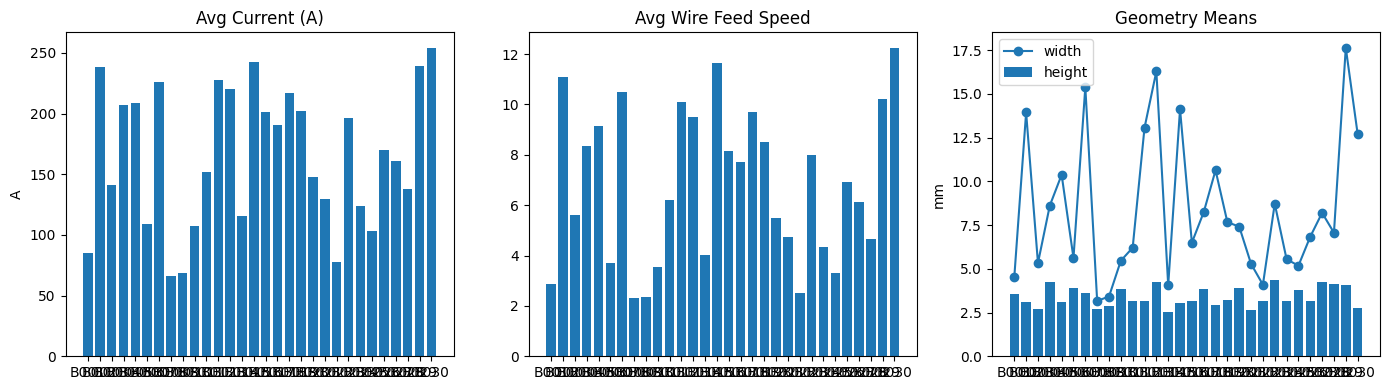

In [162]:
# Visual comparison per bead.
if not bead_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    bead_order = bead_summary.sort_values('bead_id')
    x = bead_order['bead_id'].astype(str)

    if 'current_mean' in bead_order.columns:
        axes[0].bar(x, bead_order['current_mean'])
        axes[0].set_title('Avg Current (A)')
        axes[0].set_ylabel('A')

    if 'wire_feed_speed_mean' in bead_order.columns:
        axes[1].bar(x, bead_order['wire_feed_speed_mean'])
        axes[1].set_title('Avg Wire Feed Speed')

    if 'height_mean_mm' in bead_order.columns:
        axes[2].bar(x, bead_order['height_mean_mm'], label='height')
    if 'width_mean_mm' in bead_order.columns:
        axes[2].plot(x, bead_order['width_mean_mm'], marker='o', label='width')
    axes[2].set_title('Geometry Means')
    axes[2].set_ylabel('mm')
    axes[2].legend()

    fig.tight_layout()
    out_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/bead_summary_plot.png')
    fig.savefig(out_png, dpi=150)
    print('saved bead summary plot:', out_png)


## Target vs Measured (Obtained)

This section compares bead-level **target/instructed parameters** from
`/robin/data/active_bead` against **measured/obtained parameters** from
`/robin/data/fronius`.

It also estimates obtained travel speed from Fronius progression + bead length.


In [163]:
# Load active bead target parameters.
active_rows = []
with Reader(str(BAG_PATH)) as reader:
    typestore = _build_typestore(reader)
    for conn, timestamp_ns, raw in reader.messages():
        if conn.topic != '/robin/data/active_bead':
            continue
        msg = typestore.deserialize_cdr(raw, conn.msgtype)
        active_rows.append({
            'timestamp_ns': int(timestamp_ns),
            'bead_id': str(getattr(msg, 'bead_id', '')).strip(),
            'target_current': float(getattr(msg, 'target_current', np.nan)),
            'target_voltage': float(getattr(msg, 'target_voltage', np.nan)),
            'target_wire_speed': float(getattr(msg, 'target_wire_speed', np.nan)),
            'target_speed_m_s': float(getattr(msg, 'target_speed', np.nan)),
            'total_length_m': float(getattr(msg, 'total_length', np.nan)),
        })

active_df = pd.DataFrame(active_rows).sort_values('timestamp_ns')

target_summary = (
    active_df[active_df['bead_id'] != '']
    .groupby('bead_id', as_index=False)
    .agg(
        target_messages=('bead_id', 'size'),
        target_current=('target_current', 'median'),
        target_voltage=('target_voltage', 'median'),
        target_wire_speed=('target_wire_speed', 'median'),
        target_speed_m_s=('target_speed_m_s', 'median'),
        total_length_m=('total_length_m', 'median'),
    )
)

display(target_summary)


,bead_id,target_messages,target_current,target_voltage,target_wire_speed,target_speed_m_s,total_length_m
0,B001,2,67.400002,0.0,0.0,0.00218,0.100007
1,B002,2,227.130005,0.0,0.0,0.00475,0.100003
2,B003,2,126.500000,0.0,0.0,0.00604,0.100007
3,B004,2,174.699997,0.0,0.0,0.00382,0.100003
4,B005,2,193.550003,0.0,0.0,0.00537,0.100007
5,B006,2,88.570000,0.0,0.0,0.00109,0.100003
6,B007,2,216.380005,0.0,0.0,0.00354,0.100007
7,B008,2,53.430000,0.0,0.0,0.00370,0.100003
8,B009,2,55.520000,0.0,0.0,0.00339,0.100007
9,B010,2,84.529999,0.0,0.0,0.00198,0.100003


In [164]:
# Estimate obtained travel speed using Fronius progression derivative.
obtained_speed_rows = []

for bead_id, g in fronius_valid.groupby('bead_id'):
    g = g.sort_values('timestamp_ns').copy()
    if len(g) < 3:
        continue

    # Need bead length to convert progression rate into m/s.
    length_row = target_summary[target_summary['bead_id'] == bead_id]
    if length_row.empty:
        continue
    total_length_m = float(length_row['total_length_m'].iloc[0])
    if not np.isfinite(total_length_m) or total_length_m <= 0:
        continue

    dt_s = g['timestamp_ns'].diff() / 1e9
    dp = g['progression'].diff()

    speed_m_s = (dp / dt_s) * total_length_m
    valid = (
        dt_s.notna() & (dt_s > 0) &
        dp.notna() & (dp >= 0) & (dp <= 0.2) &
        speed_m_s.notna() & np.isfinite(speed_m_s)
    )

    s = speed_m_s[valid]
    if s.empty:
        continue

    obtained_speed_rows.append({
        'bead_id': bead_id,
        'obtained_speed_samples': int(len(s)),
        'obtained_speed_m_s_mean': float(s.mean()),
        'obtained_speed_m_s_median': float(s.median()),
        'obtained_speed_m_s_p95': float(s.quantile(0.95)),
    })

obtained_speed_df = pd.DataFrame(obtained_speed_rows)
display(obtained_speed_df)


,bead_id,obtained_speed_samples,obtained_speed_m_s_mean,obtained_speed_m_s_median,obtained_speed_m_s_p95
0,B001,422,0.002363,0.002459,0.003615
1,B002,232,0.004314,0.004734,0.005784
2,B003,187,0.005322,0.005970,0.007680
3,B004,284,0.003529,0.003790,0.004904
4,B005,208,0.004790,0.005376,0.006753
5,B006,421,0.002378,0.002498,0.003182
6,B007,305,0.003256,0.003527,0.004901
7,B008,291,0.003437,0.003658,0.004680
8,B009,315,0.003187,0.003417,0.004680
9,B010,422,0.002373,0.002494,0.003151


In [165]:
# Build target-vs-measured comparison table per bead.
comparison = process_summary.merge(target_summary, on='bead_id', how='left')
comparison = comparison.merge(obtained_speed_df, on='bead_id', how='left')
if 'geometry_summary' in globals() and not geometry_summary.empty:
    comparison = comparison.merge(
        geometry_summary[['bead_id', 'height_mean_mm', 'width_mean_mm']],
        on='bead_id',
        how='left',
    )

# Absolute deltas (measured - target).
comparison['delta_current_A'] = comparison['current_mean'] - comparison['target_current']
comparison['delta_voltage_V'] = comparison['voltage_mean'] - comparison['target_voltage']
comparison['delta_wire_speed_mpm'] = comparison['wire_feed_speed_mean'] - comparison['target_wire_speed']
comparison['delta_speed_m_s'] = comparison['obtained_speed_m_s_mean'] - comparison['target_speed_m_s']

# Relative errors where target != 0.
comparison['err_current_pct'] = np.where(
    comparison['target_current'] != 0,
    100.0 * comparison['delta_current_A'] / comparison['target_current'],
    np.nan,
)
comparison['err_voltage_pct'] = np.where(
    comparison['target_voltage'] != 0,
    100.0 * comparison['delta_voltage_V'] / comparison['target_voltage'],
    np.nan,
)
comparison['err_wire_speed_pct'] = np.where(
    comparison['target_wire_speed'] != 0,
    100.0 * comparison['delta_wire_speed_mpm'] / comparison['target_wire_speed'],
    np.nan,
)
comparison['err_speed_pct'] = np.where(
    comparison['target_speed_m_s'] != 0,
    100.0 * comparison['delta_speed_m_s'] / comparison['target_speed_m_s'],
    np.nan,
)

for col in ['height_mean_mm', 'width_mean_mm']:
    if col not in comparison.columns:
        comparison[col] = np.nan

comparison_cols = [
    'bead_id',
    'target_current', 'current_mean', 'delta_current_A', 'err_current_pct',
    'target_voltage', 'voltage_mean', 'delta_voltage_V', 'err_voltage_pct',
    'target_wire_speed', 'wire_feed_speed_mean', 'delta_wire_speed_mpm', 'err_wire_speed_pct',
    'target_speed_m_s', 'obtained_speed_m_s_mean', 'delta_speed_m_s', 'err_speed_pct',
    'height_mean_mm', 'width_mean_mm'
]
comparison_view = comparison[comparison_cols].sort_values('bead_id')
display(comparison_view)

out_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/target_vs_measured_bead.csv')
comparison_view.to_csv(out_csv, index=False)
print('saved target-vs-measured csv:', out_csv)


,bead_id,target_current,current_mean,delta_current_A,err_current_pct,target_voltage,voltage_mean,delta_voltage_V,err_voltage_pct,target_wire_speed,wire_feed_speed_mean,delta_wire_speed_mpm,err_wire_speed_pct,target_speed_m_s,obtained_speed_m_s_mean,delta_speed_m_s,err_speed_pct,height_mean_mm,width_mean_mm
0,B001,67.400002,84.996440,17.596439,26.107475,0.0,13.997552,13.997552,NaN,0.0,2.857861,2.857861,NaN,0.00218,0.002363,0.000183,8.383652,3.581323,4.513384
1,B002,227.130005,238.624020,11.494015,5.060545,0.0,25.379781,25.379781,NaN,0.0,11.095707,11.095707,NaN,0.00475,0.004314,-0.000436,-9.186314,3.130428,13.941229
2,B003,126.500000,141.007134,14.507134,11.468090,0.0,17.020014,17.020014,NaN,0.0,5.592254,5.592254,NaN,0.00604,0.005322,-0.000718,-11.884947,2.712664,5.332022
3,B004,174.699997,207.395602,32.695605,18.715287,0.0,15.345407,15.345407,NaN,0.0,8.342854,8.342854,NaN,0.00382,0.003529,-0.000291,-7.608165,4.230149,8.613885
4,B005,193.550003,208.799652,15.249649,7.878920,0.0,21.349424,21.349424,NaN,0.0,9.126423,9.126423,NaN,0.00537,0.004790,-0.000580,-10.797105,3.108393,10.377593
5,B006,88.570000,108.838567,20.268567,22.884236,0.0,14.357706,14.357706,NaN,0.0,3.717821,3.717821,NaN,0.00109,0.002378,0.001288,118.178811,3.882832,5.622945
6,B007,216.380005,225.708762,9.328757,4.311284,0.0,23.935166,23.935166,NaN,0.0,10.504031,10.504031,NaN,0.00354,0.003256,-0.000284,-8.019345,3.600913,15.390622
7,B008,53.430000,66.212407,12.782407,23.923651,0.0,14.107273,14.107273,NaN,0.0,2.295149,2.295149,NaN,0.00370,0.003437,-0.000263,-7.111966,2.707294,3.169929
8,B009,55.520000,69.004056,13.484055,24.286843,0.0,14.540563,14.540563,NaN,0.0,2.363103,2.363103,NaN,0.00339,0.003187,-0.000203,-5.998917,2.897522,3.413652
9,B010,84.529999,107.489268,22.959269,27.161090,0.0,14.055099,14.055099,NaN,0.0,3.543818,3.543818,NaN,0.00198,0.002373,0.000393,19.844973,3.825723,5.461091


saved target-vs-measured csv: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/target_vs_measured_bead.csv


saved target-vs-measured plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/target_vs_measured_plot.png


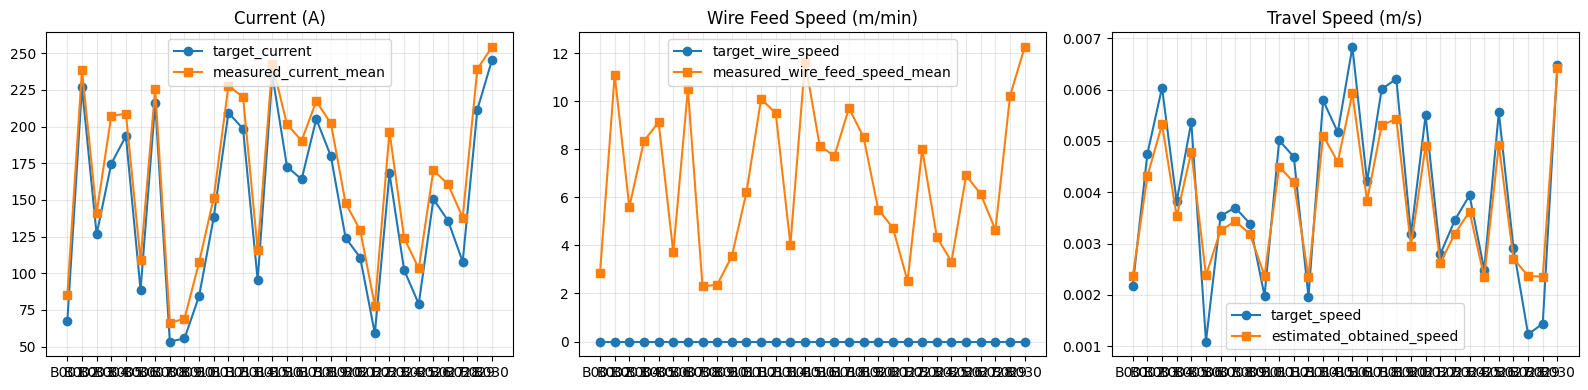

In [166]:
# Plot measured vs target by bead (current + speed channels).
if not comparison.empty:
    c = comparison.sort_values('bead_id')
    labels = c['bead_id'].astype(str)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Current
    axes[0].plot(labels, c['target_current'], marker='o', label='target_current')
    axes[0].plot(labels, c['current_mean'], marker='s', label='measured_current_mean')
    axes[0].set_title('Current (A)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Wire feed speed (m/min)
    axes[1].plot(labels, c['target_wire_speed'], marker='o', label='target_wire_speed')
    axes[1].plot(labels, c['wire_feed_speed_mean'], marker='s', label='measured_wire_feed_speed_mean')
    axes[1].set_title('Wire Feed Speed (m/min)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Travel speed (m/s) target vs estimated obtained
    axes[2].plot(labels, c['target_speed_m_s'], marker='o', label='target_speed')
    axes[2].plot(labels, c['obtained_speed_m_s_mean'], marker='s', label='estimated_obtained_speed')
    axes[2].set_title('Travel Speed (m/s)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    fig.tight_layout()
    out_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/target_vs_measured_plot.png')
    fig.savefig(out_png, dpi=150)
    print('saved target-vs-measured plot:', out_png)


## Design Space Points and 3D Response Surfaces

This section visualizes:

- measured process points in design space
- target/instructed points overlay
- 3D response surfaces from measured process -> geometry


In [167]:
# Build design-space frame from merged process + geometry rows.
if 'merged' not in globals() or merged is None or merged.empty:
    design_df = pd.DataFrame()
else:
    design_df = merged.copy()

if not design_df.empty:
    # Keep rows with complete process + geometry measurements.
    required = ['current', 'voltage', 'wire_feed_speed', 'height_mm', 'width_mm']
    design_df = design_df.dropna(subset=required)

    # Prefer geometry bead id when available.
    if 'bead_id_geom' in design_df.columns:
        design_df['bead_id'] = design_df['bead_id_geom'].fillna('').astype(str)
    elif 'bead_id' in design_df.columns:
        design_df['bead_id'] = design_df['bead_id'].fillna('').astype(str)
    else:
        design_df['bead_id'] = ''

    # Remove obvious non-physical geometry rows.
    design_df = design_df[(design_df['height_mm'] > 0) & (design_df['width_mm'] > 0)]

print('design_df rows:', len(design_df))
if not design_df.empty:
    print('current range:', (float(design_df['current'].min()), float(design_df['current'].max())))
    print('voltage range:', (float(design_df['voltage'].min()), float(design_df['voltage'].max())))
    print('wire_feed_speed range:', (float(design_df['wire_feed_speed'].min()), float(design_df['wire_feed_speed'].max())))


design_df rows: 34335
current range: (0.0, 276.2875061035156)
voltage range: (0.0, 65.64375305175781)
wire_feed_speed range: (0.0, 12.418749809265137)


saved design-space plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/design_space_points.png


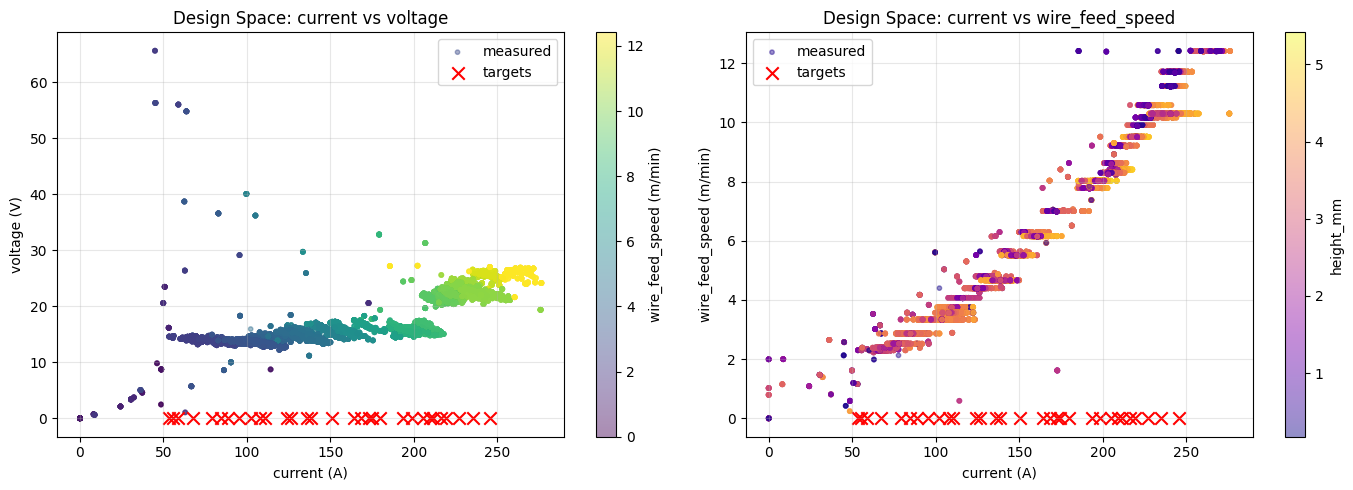

In [168]:
# 2D design-space point clouds with target overlays.
if not design_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Measured process cloud: current vs voltage, colored by wire feed speed.
    sc0 = axes[0].scatter(
        design_df['current'],
        design_df['voltage'],
        c=design_df['wire_feed_speed'],
        s=10,
        alpha=0.45,
        cmap='viridis',
        label='measured',
    )
    axes[0].set_xlabel('current (A)')
    axes[0].set_ylabel('voltage (V)')
    axes[0].set_title('Design Space: current vs voltage')
    cb0 = plt.colorbar(sc0, ax=axes[0])
    cb0.set_label('wire_feed_speed (m/min)')

    # Overlay target points if available.
    if 'target_summary' in globals() and not target_summary.empty:
        axes[0].scatter(
            target_summary['target_current'],
            target_summary['target_voltage'],
            c='red',
            marker='x',
            s=80,
            label='targets',
        )
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Measured process cloud: current vs wire feed speed, colored by mean height.
    sc1 = axes[1].scatter(
        design_df['current'],
        design_df['wire_feed_speed'],
        c=design_df['height_mm'],
        s=10,
        alpha=0.45,
        cmap='plasma',
        label='measured',
    )
    axes[1].set_xlabel('current (A)')
    axes[1].set_ylabel('wire_feed_speed (m/min)')
    axes[1].set_title('Design Space: current vs wire_feed_speed')
    cb1 = plt.colorbar(sc1, ax=axes[1])
    cb1.set_label('height_mm')

    if 'target_summary' in globals() and not target_summary.empty:
        axes[1].scatter(
            target_summary['target_current'],
            target_summary['target_wire_speed'],
            c='red',
            marker='x',
            s=80,
            label='targets',
        )
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    out_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/design_space_points.png')
    fig.savefig(out_png, dpi=150)
    print('saved design-space plot:', out_png)


In [169]:
### can you add plots of current and voltage versus stickout in this cell?



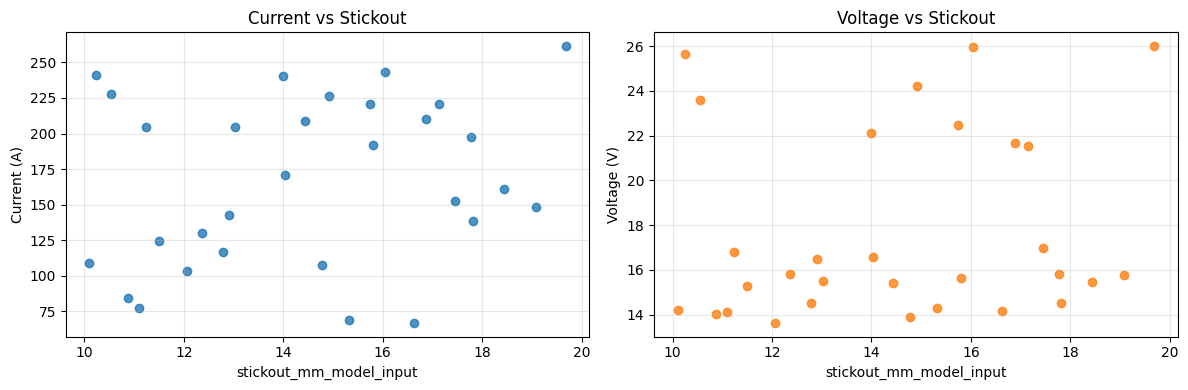

In [170]:
# Current and voltage versus stickout
try:
    df = model_df
except NameError:
    gold_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/data/gold/train_dataset.csv')
    df = pd.read_csv(gold_csv)
if 'quality_flag' in df.columns:
    df = df[df['quality_flag'] == 'ok'].copy()
cur_col = 'measured_current_A_mean' if 'measured_current_A_mean' in df.columns else 'target_current_A'
vol_col = 'measured_voltage_V_mean' if 'measured_voltage_V_mean' in df.columns else 'target_voltage_V'
plot_df = df[[cur_col, vol_col, 'stickout_mm_model_input']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(plot_df['stickout_mm_model_input'], plot_df[cur_col], alpha=0.8, c='tab:blue')
axes[0].set_xlabel('stickout_mm_model_input')
axes[0].set_ylabel('Current (A)')
axes[0].set_title('Current vs Stickout')
axes[0].grid(alpha=0.3)
axes[1].scatter(plot_df['stickout_mm_model_input'], plot_df[vol_col], alpha=0.8, c='tab:orange')
axes[1].set_xlabel('stickout_mm_model_input')
axes[1].set_ylabel('Voltage (V)')
axes[1].set_title('Voltage vs Stickout')
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

saved 3D response-surface plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/response_surface_3d.png


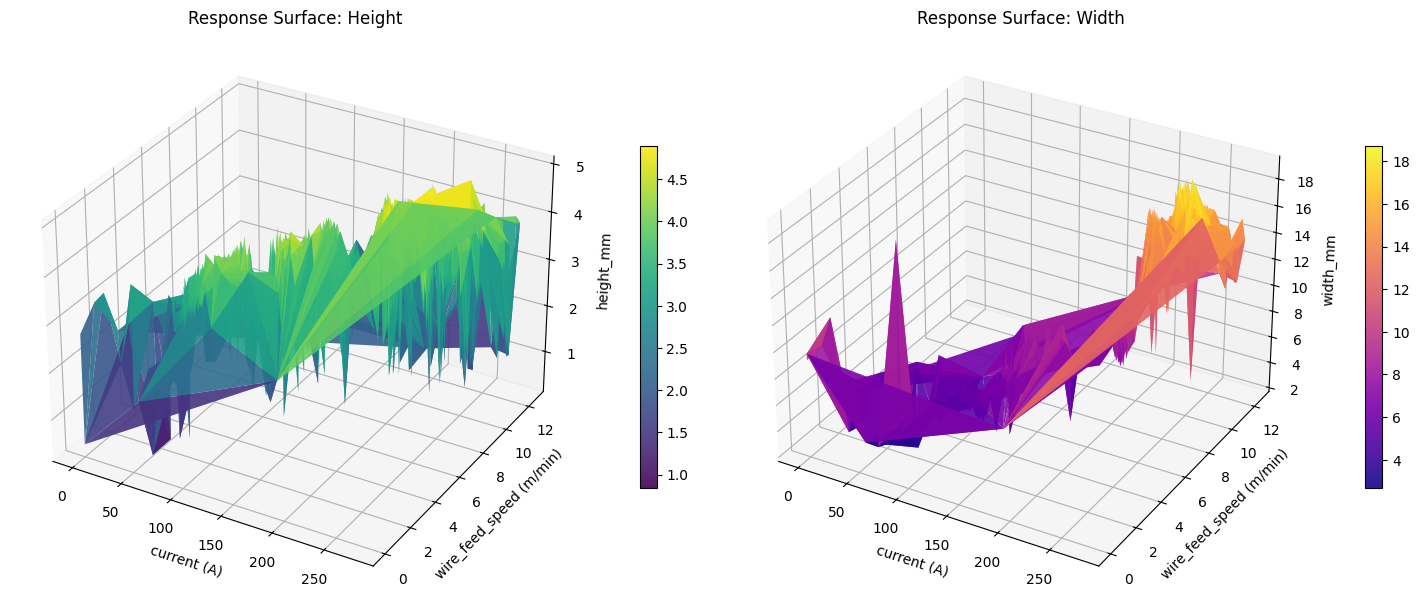

In [171]:
# 3D response-surface style plots from measured points.
# Axes: current (A), wire_feed_speed (m/min), response in mm.
if not design_df.empty:
    # Downsample for faster triangulation if needed.
    surf_df = design_df
    if len(surf_df) > 2500:
        surf_df = surf_df.sample(n=2500, random_state=42)

    x = surf_df['current'].to_numpy()
    y = surf_df['wire_feed_speed'].to_numpy()
    z_h = surf_df['height_mm'].to_numpy()
    z_w = surf_df['width_mm'].to_numpy()

    fig = plt.figure(figsize=(15, 6))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    tris1 = ax1.plot_trisurf(x, y, z_h, cmap='viridis', linewidth=0.1, alpha=0.9)
    ax1.set_xlabel('current (A)')
    ax1.set_ylabel('wire_feed_speed (m/min)')
    ax1.set_zlabel('height_mm')
    ax1.set_title('Response Surface: Height')
    fig.colorbar(tris1, ax=ax1, shrink=0.6, pad=0.08)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    tris2 = ax2.plot_trisurf(x, y, z_w, cmap='plasma', linewidth=0.1, alpha=0.9)
    ax2.set_xlabel('current (A)')
    ax2.set_ylabel('wire_feed_speed (m/min)')
    ax2.set_zlabel('width_mm')
    ax2.set_title('Response Surface: Width')
    fig.colorbar(tris2, ax=ax2, shrink=0.6, pad=0.08)

    fig.tight_layout()
    out_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/response_surface_3d.png')
    fig.savefig(out_png, dpi=150)
    print('saved 3D response-surface plot:', out_png)


## Stickout Feature Diagnostics

This section uses the cleaned gold dataset to understand why adding stickout does or does not improve performance.

It includes:

- feature/response correlation analysis
- scatter diagnostics for stickout vs responses
- repeated cross-validated feature-set ablation


In [172]:
# Load cleaned gold dataset used for training.
gold_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/data/gold/train_dataset.csv')
assert gold_csv.exists(), f'Gold dataset not found: {gold_csv}'

train_df = pd.read_csv(gold_csv)
if 'quality_flag' in train_df.columns:
    model_df = train_df[train_df['quality_flag'] == 'ok'].copy()
else:
    model_df = train_df.copy()

core_cols = [
    'target_current_A',
    'target_travel_speed_mps',
    'wire_speed_mpm_model_input',
    'stickout_mm_model_input',
    'height_mm_target',
    'width_mm_target',
]
for c in core_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce')

model_df = model_df.dropna(subset=core_cols).copy()

print('gold csv:', gold_csv)
print('rows total:', len(train_df), 'rows used (quality=ok + complete):', len(model_df))
display(model_df[['bead_id'] + core_cols].head(12))
display(model_df[core_cols].describe().T)


gold csv: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/data/gold/train_dataset.csv
rows total: 30 rows used (quality=ok + complete): 30


,bead_id,target_current_A,target_travel_speed_mps,wire_speed_mpm_model_input,stickout_mm_model_input,height_mm_target,width_mm_target
0,B001,67.400002,0.00218,2.865625,10.87,3.638789,4.429294
1,B002,227.130005,0.00475,11.224609,10.24,3.501241,14.186038
2,B003,126.500000,0.00604,5.635156,12.91,2.812763,5.265443
3,B004,174.699997,0.00382,8.403906,14.44,4.504272,8.453199
4,B005,193.550003,0.00537,9.212891,16.88,3.358879,10.551238
5,B006,88.570000,0.00109,3.756250,10.10,3.978865,5.568581
6,B007,216.380005,0.00354,10.580469,14.92,3.944074,15.578681
7,B008,53.430000,0.00370,2.299219,16.62,2.779286,3.016320
8,B009,55.520000,0.00339,2.384766,15.32,2.941503,3.270975
9,B010,84.529999,0.00198,3.567969,14.77,3.917446,5.356959


,count,mean,std,min,25%,50%,75%,max
target_current_A,30.0,146.031668,58.737780,53.430000,96.940001,144.459999,197.300003,245.460007
target_travel_speed_mps,30.0,0.004024,0.001675,0.001090,0.002820,0.003880,0.005467,0.006830
wire_speed_mpm_model_input,30.0,6.846393,3.091353,2.299219,4.150195,6.646094,9.435254,12.408203
stickout_mm_model_input,30.0,14.489667,2.839334,10.100000,12.137500,14.605000,16.815000,19.680000
height_mm_target,30.0,3.616618,0.585125,2.638429,3.274943,3.460992,4.062050,4.626641
width_mm_target,30.0,8.386888,4.229812,3.016320,5.305735,7.098324,10.782962,18.059890


,target_current_A,target_travel_speed_mps,wire_speed_mpm_model_input,stickout_mm_model_input,height_mm_target,width_mm_target
target_current_A,1.000000,0.402000,0.998734,0.220574,0.229073,0.882931
target_travel_speed_mps,0.402000,1.000000,0.403051,-0.010305,-0.629539,0.002986
wire_speed_mpm_model_input,0.998734,0.403051,1.000000,0.218468,0.216804,0.883836
stickout_mm_model_input,0.220574,-0.010305,0.218468,1.000000,0.296427,0.199068
height_mm_target,0.229073,-0.629539,0.216804,0.296427,1.000000,0.391044
width_mm_target,0.882931,0.002986,0.883836,0.199068,0.391044,1.000000


saved correlation matrix: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_correlation_matrix.png
saved scatter diagnostics: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_scatter_diagnostics.png
corr(stickout, height): 0.29642671792473724
corr(stickout, width) : 0.199067984648632
corr(wire, width)     : 0.8838360573925175


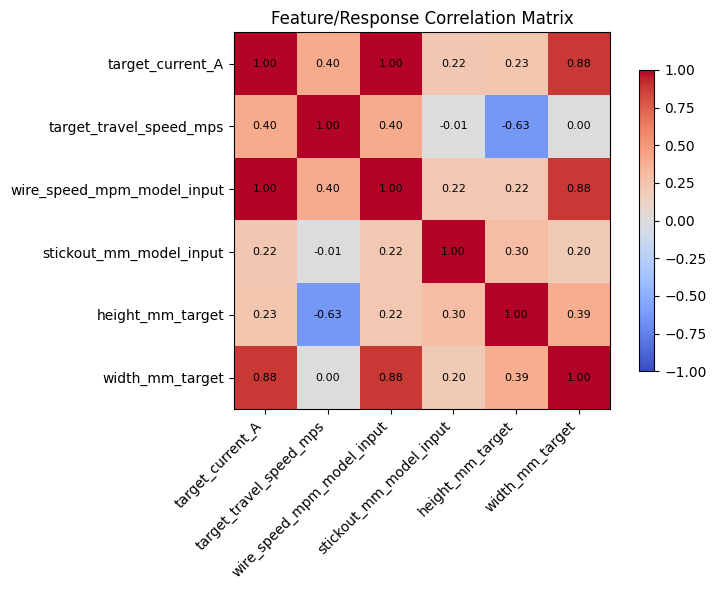

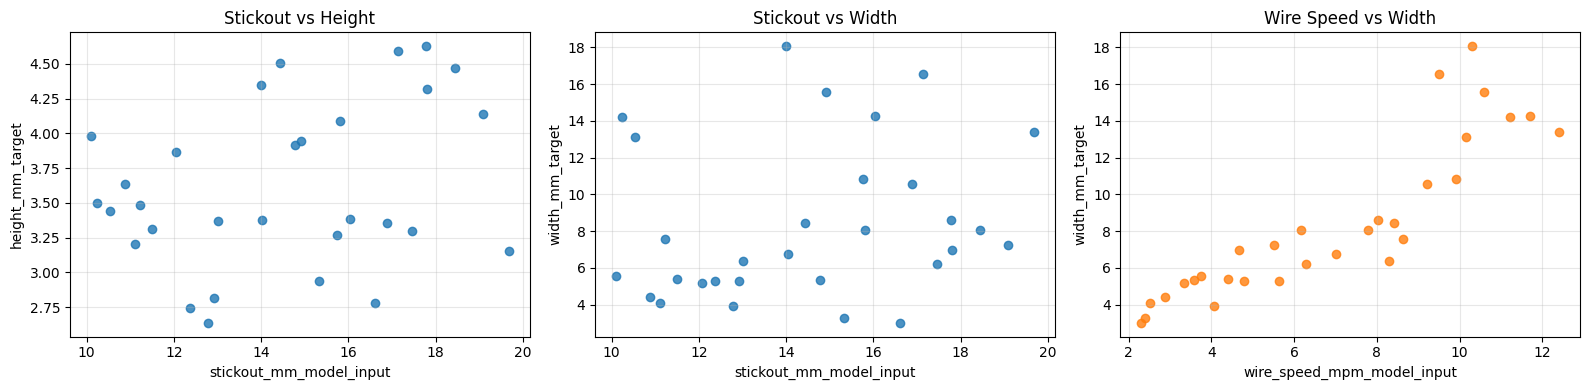

In [173]:
# Correlation matrix + scatter diagnostics.
corr_cols = [
    'target_current_A',
    'target_travel_speed_mps',
    'wire_speed_mpm_model_input',
    'stickout_mm_model_input',
    'height_mm_target',
    'width_mm_target',
]
corr = model_df[corr_cols].corr()
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Feature/Response Correlation Matrix')
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
corr_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_correlation_matrix.png')
fig.savefig(corr_png, dpi=150)
print('saved correlation matrix:', corr_png)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(model_df['stickout_mm_model_input'], model_df['height_mm_target'], alpha=0.8)
axes[0].set_xlabel('stickout_mm_model_input')
axes[0].set_ylabel('height_mm_target')
axes[0].set_title('Stickout vs Height')
axes[0].grid(alpha=0.3)

axes[1].scatter(model_df['stickout_mm_model_input'], model_df['width_mm_target'], alpha=0.8)
axes[1].set_xlabel('stickout_mm_model_input')
axes[1].set_ylabel('width_mm_target')
axes[1].set_title('Stickout vs Width')
axes[1].grid(alpha=0.3)

axes[2].scatter(model_df['wire_speed_mpm_model_input'], model_df['width_mm_target'], alpha=0.8, c='tab:orange')
axes[2].set_xlabel('wire_speed_mpm_model_input')
axes[2].set_ylabel('width_mm_target')
axes[2].set_title('Wire Speed vs Width')
axes[2].grid(alpha=0.3)

fig.tight_layout()
scatter_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_scatter_diagnostics.png')
fig.savefig(scatter_png, dpi=150)
print('saved scatter diagnostics:', scatter_png)

print('corr(stickout, height):', float(corr.loc['stickout_mm_model_input', 'height_mm_target']))
print('corr(stickout, width) :', float(corr.loc['stickout_mm_model_input', 'width_mm_target']))
print('corr(wire, width)     :', float(corr.loc['wire_speed_mpm_model_input', 'width_mm_target']))


,feature_set,n_features,cv_r2_mean,cv_r2_std
0,current+travel+wire,3,0.828584,0.171793
3,current+travel,2,0.825940,0.167704
2,current+travel+wire+stickout,4,0.818025,0.191930
1,current+travel+stickout,3,0.813686,0.191867


saved feature ablation plot: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_feature_ablation_cv.png


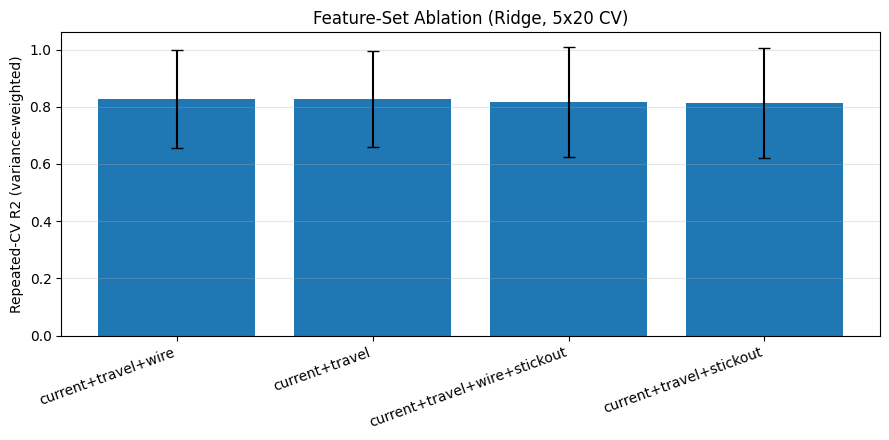

In [174]:
# Repeated-CV feature-set ablation (variance-weighted R2 on multi-output).
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

target_cols = ['height_mm_target', 'width_mm_target']
feature_sets = {
    'current+travel+wire': ['target_current_A', 'target_travel_speed_mps', 'wire_speed_mpm_model_input'],
    'current+travel+stickout': ['target_current_A', 'target_travel_speed_mps', 'stickout_mm_model_input'],
    'current+travel+wire+stickout': ['target_current_A', 'target_travel_speed_mps', 'wire_speed_mpm_model_input', 'stickout_mm_model_input'],
    'current+travel': ['target_current_A', 'target_travel_speed_mps'],
}

cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)
scorer = make_scorer(r2_score, multioutput='variance_weighted')

rows = []
y = model_df[target_cols].to_numpy()
for name, feats in feature_sets.items():
    X = model_df[feats].to_numpy()
    reg = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0)),
    ])
    scores = cross_val_score(reg, X, y, cv=cv, scoring=scorer)
    rows.append({
        'feature_set': name,
        'n_features': len(feats),
        'cv_r2_mean': float(scores.mean()),
        'cv_r2_std': float(scores.std()),
    })

ablation_df = pd.DataFrame(rows).sort_values('cv_r2_mean', ascending=False)
display(ablation_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(ablation_df['feature_set'], ablation_df['cv_r2_mean'], yerr=ablation_df['cv_r2_std'], capsize=4)
ax.set_ylabel('Repeated-CV R2 (variance-weighted)')
ax.set_title('Feature-Set Ablation (Ridge, 5x20 CV)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
ablation_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/stickout_feature_ablation_cv.png')
fig.savefig(ablation_png, dpi=150)
print('saved feature ablation plot:', ablation_png)


## DOE Guidance: Regions Likely To Improve Model Score

Reasoning used in this section:

- New experiments help most where model uncertainty is high.
- They also help where repeated-CV residuals are high (model currently struggles).
- They should expand coverage into under-sampled areas (distance from existing points).

We combine these into a practical acquisition score for ranking next DOE points.


In [175]:
# Build a clean modeling table for DOE guidance analysis.
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import RepeatedKFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

gold_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/data/gold/train_dataset.csv')
df = pd.read_csv(gold_csv)
if 'quality_flag' in df.columns:
    df = df[df['quality_flag'] == 'ok'].copy()

feature_cols = ['target_current_A', 'target_travel_speed_mps', 'stickout_mm_model_input']
target_cols = ['height_mm_target', 'width_mm_target']
for c in feature_cols + target_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=feature_cols + target_cols).copy()

X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

print('rows used:', len(df))
print('feature ranges:')
for c in feature_cols:
    print(' -', c, (float(df[c].min()), float(df[c].max())))
display(df[['bead_id'] + feature_cols + target_cols].head(12))


rows used: 30
feature ranges:
 - target_current_A (53.43000030517578, 245.4600067138672)
 - target_travel_speed_mps (0.0010900000343099, 0.0068299998529255)
 - stickout_mm_model_input (10.1, 19.68)


,bead_id,target_current_A,target_travel_speed_mps,stickout_mm_model_input,height_mm_target,width_mm_target
0,B001,67.400002,0.00218,10.87,3.638789,4.429294
1,B002,227.130005,0.00475,10.24,3.501241,14.186038
2,B003,126.500000,0.00604,12.91,2.812763,5.265443
3,B004,174.699997,0.00382,14.44,4.504272,8.453199
4,B005,193.550003,0.00537,16.88,3.358879,10.551238
5,B006,88.570000,0.00109,10.10,3.978865,5.568581
6,B007,216.380005,0.00354,14.92,3.944074,15.578681
7,B008,53.430000,0.00370,16.62,2.779286,3.016320
8,B009,55.520000,0.00339,15.32,2.941503,3.270975
9,B010,84.529999,0.00198,14.77,3.917446,5.356959


Repeated-CV generalized R2 mean/std: 0.8136857992222398 0.19186706956970767
OOF test-count per sample (should all be n_repeats): [20]
mean OOF sample RMSE: 0.7901459176351248
mean in-sample RMSE : 0.6745437025096273


,bead_id,target_current_A,target_travel_speed_mps,stickout_mm_model_input,cv_sample_rmse
28,B029,211.610001,0.00144,14.00,2.225151
12,B013,198.550003,0.00196,17.14,2.118286
3,B004,174.699997,0.00382,14.44,1.701694
5,B006,88.570000,0.00109,10.10,1.492825
22,B023,168.210007,0.00346,17.77,1.447744
6,B007,216.380005,0.00354,14.92,1.285558
15,B016,172.800003,0.00683,13.02,1.130988
16,B017,164.009995,0.00421,15.81,1.099789
18,B019,179.770004,0.00621,11.23,1.097275
7,B008,53.430000,0.00370,16.62,1.075772


saved residual map: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_residual_maps.png


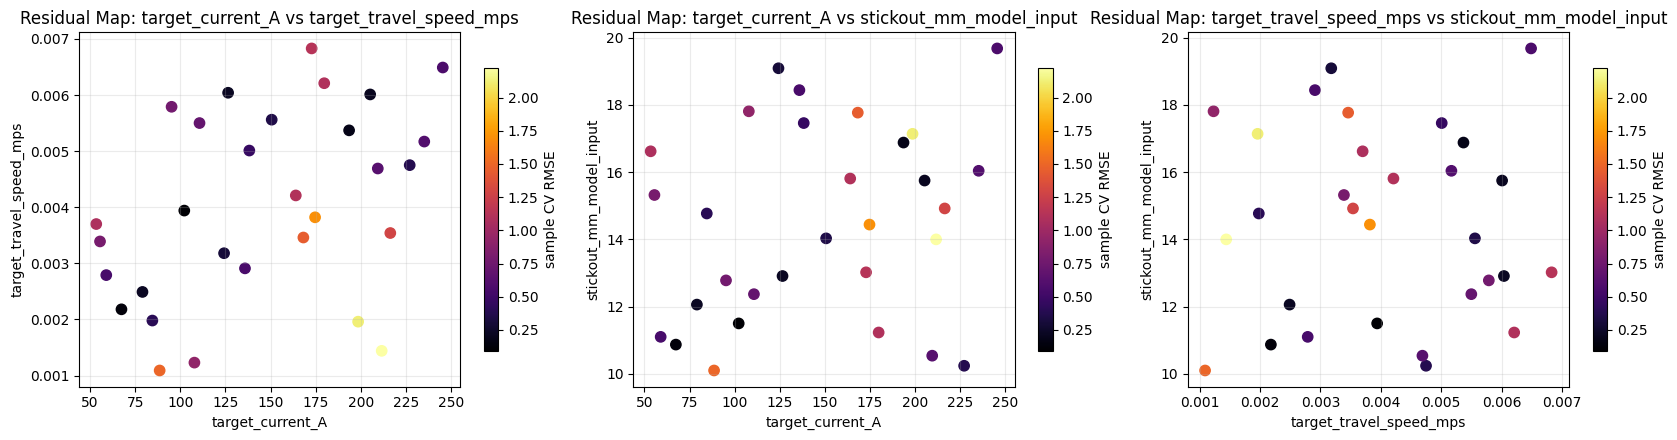

In [176]:
# 1) Repeated-CV sample-level residual analysis (where model struggles).
rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=42)
base_model = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])

n = len(df)
counts = np.zeros(n, dtype=int)
rmse_sum = np.zeros(n, dtype=float)
fold_r2 = []

for tr, te in rkf.split(X):
    model = clone(base_model)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[te])
    fold_r2.append(r2_score(y[te], pred, multioutput='variance_weighted'))
    rmse = np.sqrt(np.mean((pred - y[te]) ** 2, axis=1))
    rmse_sum[te] += rmse
    counts[te] += 1

df['cv_sample_rmse'] = rmse_sum / np.maximum(counts, 1)

# Leakage guard: every sample error here is out-of-fold only.
expected_oof_count = rkf.n_repeats
assert int(counts.min()) == expected_oof_count and int(counts.max()) == expected_oof_count, (
    f'Unexpected OOF count range: min={int(counts.min())}, max={int(counts.max())}, expected={expected_oof_count}'
)

# Show that OOF error is not optimistic relative to in-sample fit.
full_model = clone(base_model).fit(X, y)
full_pred = full_model.predict(X)
insample_rmse = np.sqrt(np.mean((full_pred - y) ** 2, axis=1))

print('Repeated-CV generalized R2 mean/std:', float(np.mean(fold_r2)), float(np.std(fold_r2)))
print('OOF test-count per sample (should all be n_repeats):', sorted(np.unique(counts).tolist()))
print('mean OOF sample RMSE:', float(df['cv_sample_rmse'].mean()))
print('mean in-sample RMSE :', float(insample_rmse.mean()))
display(df[['bead_id'] + feature_cols + ['cv_sample_rmse']].sort_values('cv_sample_rmse', ascending=False).head(10))

pairs = [
    ('target_current_A', 'target_travel_speed_mps'),
    ('target_current_A', 'stickout_mm_model_input'),
    ('target_travel_speed_mps', 'stickout_mm_model_input'),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (xcol, ycol) in zip(axes, pairs):
    sc = ax.scatter(df[xcol], df[ycol], c=df['cv_sample_rmse'], cmap='inferno', s=55)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'Residual Map: {xcol} vs {ycol}')
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, shrink=0.8, label='sample CV RMSE')
fig.tight_layout()

resid_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_residual_maps.png')
fig.savefig(resid_png, dpi=150)
print('saved residual map:', resid_png)



saved uncertainty/coverage maps: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_uncertainty_coverage_maps.png


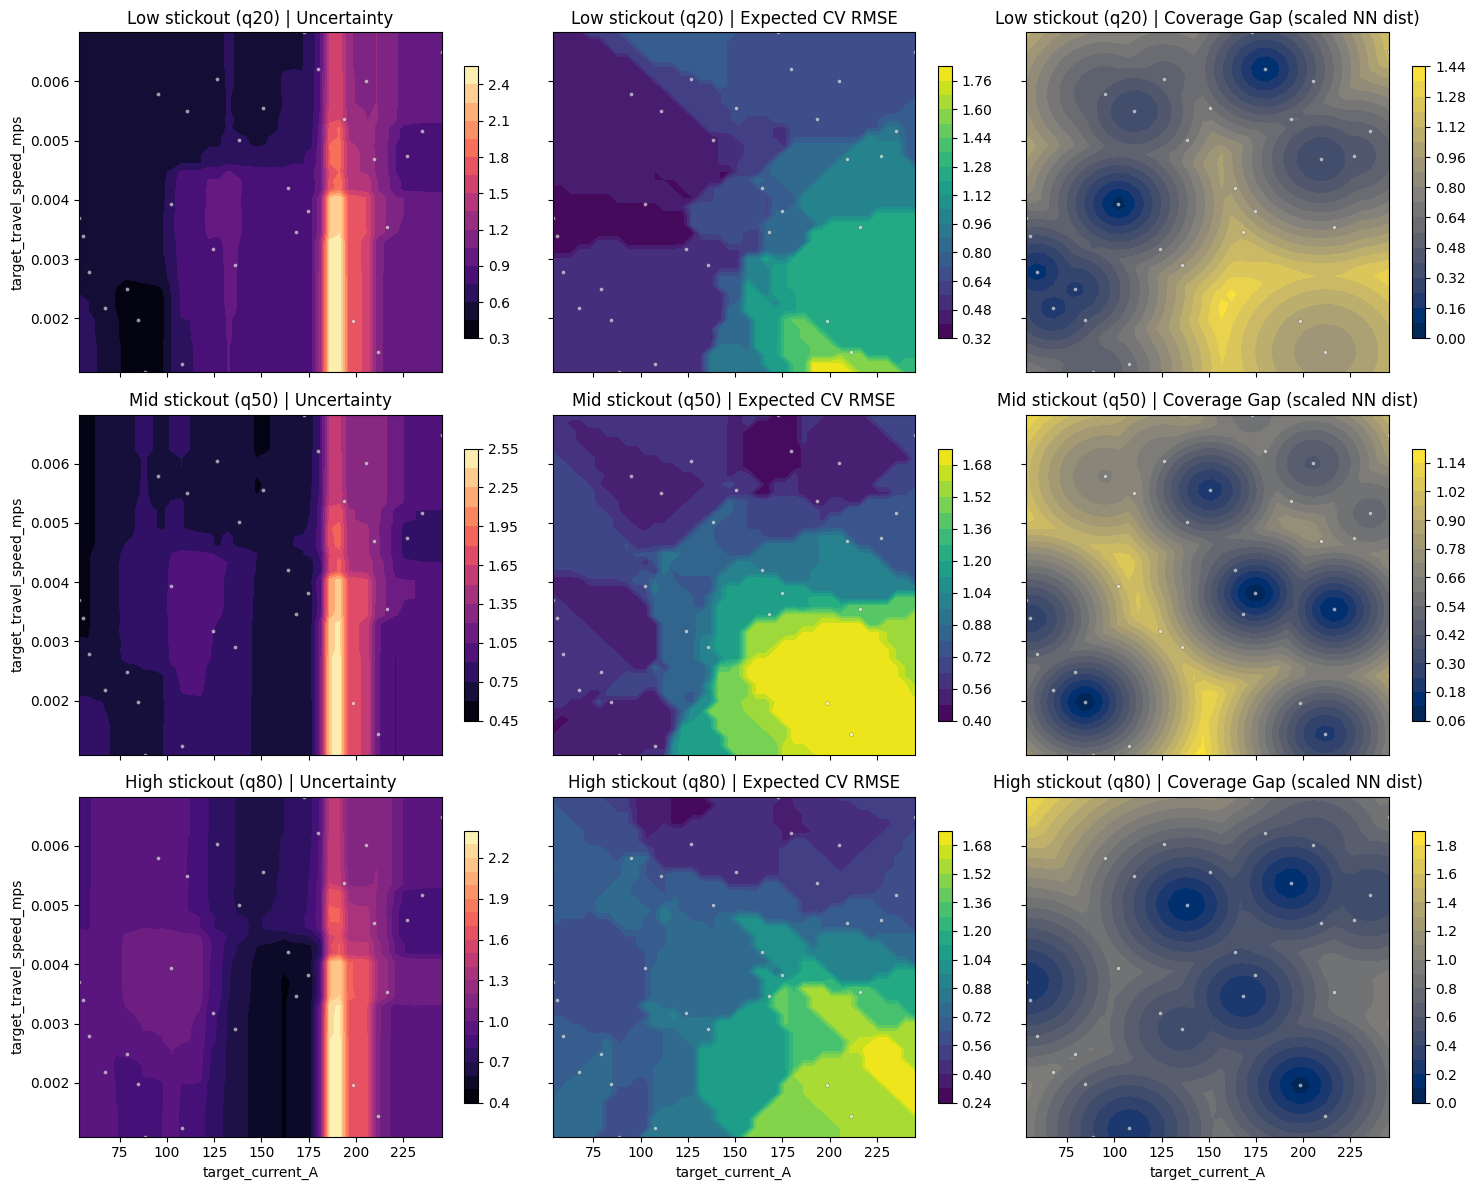

In [177]:
# 2) Uncertainty and coverage maps on current-speed planes at stickout slices.
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1,
)
rf.fit(X, y)

# Standardize feature space for distance-based metrics.
distance_scaler = StandardScaler().fit(X)
X_scaled = distance_scaler.transform(X)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_scaled)

err_knn = KNeighborsRegressor(n_neighbors=min(7, len(df)), weights='distance')
err_knn.fit(X_scaled, df['cv_sample_rmse'].to_numpy())

cur_grid = np.linspace(df['target_current_A'].min(), df['target_current_A'].max(), 40)
spd_grid = np.linspace(df['target_travel_speed_mps'].min(), df['target_travel_speed_mps'].max(), 40)
stick_slices = np.quantile(df['stickout_mm_model_input'], [0.2, 0.5, 0.8])
slice_labels = ['Low stickout (q20)', 'Mid stickout (q50)', 'High stickout (q80)']

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
for i, (sval, slabel) in enumerate(zip(stick_slices, slice_labels)):
    C, S = np.meshgrid(cur_grid, spd_grid)
    G = np.column_stack([C.ravel(), S.ravel(), np.full(C.size, sval)])
    G_scaled = distance_scaler.transform(G)

    # Ensemble uncertainty from tree spread.
    tree_preds = np.stack([est.predict(G) for est in rf.estimators_], axis=0)  # trees x points x targets
    pred_std = tree_preds.std(axis=0)
    uncertainty = np.sqrt(np.mean(pred_std ** 2, axis=1))

    # Distance to nearest observed sample (coverage gap) in standardized space.
    dist, _ = nn.kneighbors(G_scaled, n_neighbors=1)
    coverage_gap = dist.ravel()

    # Expected local error from KNN regressor on sample CV residuals (standardized space).
    expected_rmse = err_knn.predict(G_scaled)

    metrics = [
        ('Uncertainty', uncertainty, 'magma'),
        ('Expected CV RMSE', expected_rmse, 'viridis'),
        ('Coverage Gap (scaled NN dist)', coverage_gap, 'cividis'),
    ]

    for j, (title, arr, cmap) in enumerate(metrics):
        ax = axes[i, j]
        z = arr.reshape(C.shape)
        im = ax.contourf(C, S, z, levels=18, cmap=cmap)
        ax.scatter(df['target_current_A'], df['target_travel_speed_mps'], s=8, c='white', edgecolors='k', linewidths=0.2, alpha=0.6)
        ax.set_title(f'{slabel} | {title}')
        if i == 2:
            ax.set_xlabel('target_current_A')
        if j == 0:
            ax.set_ylabel('target_travel_speed_mps')
        plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
maps_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_uncertainty_coverage_maps.png')
fig.savefig(maps_png, dpi=150)
print('saved uncertainty/coverage maps:', maps_png)



,target_current_A,target_travel_speed_mps,stickout_mm_model_input,acquisition_score,uncertainty,expected_cv_rmse,coverage_gap,pred_height_mm,pred_width_mm,selection_utility
0,188.562227,0.001090,12.228889,3.004334,2.859635,1.764703,0.779073,4.030440,12.698213,4.260297
1,188.562227,0.001728,12.228889,2.997972,2.859635,1.764703,0.769625,4.030440,12.698213,4.522359
2,188.562227,0.001303,12.228889,2.987556,2.859635,1.764703,0.754156,4.030440,12.698213,4.326867
3,188.562227,0.001515,12.228889,2.985374,2.859635,1.764703,0.750915,4.030440,12.698213,4.323773
4,188.562227,0.002153,10.100000,2.962383,2.857227,1.284801,1.516053,4.034796,12.699739,4.900161
5,188.562227,0.002578,13.293333,2.958118,2.862075,1.686096,0.837229,4.038819,12.727191,4.728583
6,188.562227,0.001940,10.100000,2.941041,2.857227,1.284801,1.484356,4.034796,12.699739,4.260906
7,188.562227,0.001728,10.100000,2.926930,2.857227,1.284801,1.463399,4.034796,12.699739,4.240896
8,188.562227,0.001515,10.100000,2.920363,2.857227,1.284801,1.453646,4.034796,12.699739,4.412305
9,188.562227,0.001940,11.164444,2.907753,2.857227,1.466975,1.132835,4.034796,12.699739,4.405132


saved candidate ranking plots: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_candidate_ranking.png
saved top candidate table: /Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_top_candidates.csv


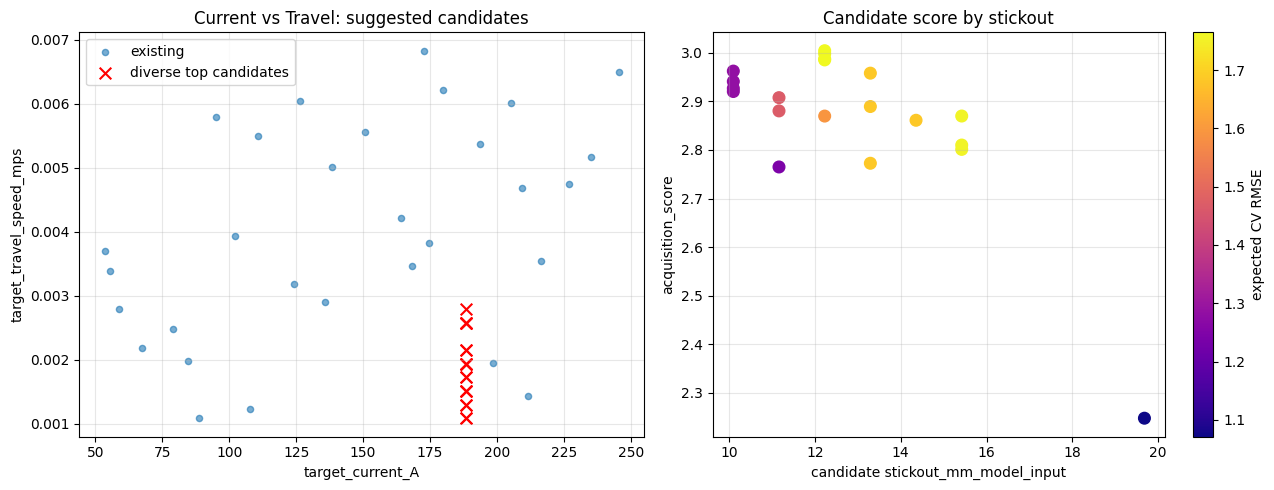

In [178]:
# 3) Engineer-step candidates + constrained diverse exploration + separate replicates.
def zscore(v):
    v = np.asarray(v, dtype=float)
    s = v.std()
    if s == 0 or np.isnan(s):
        return np.zeros_like(v)
    return (v - v.mean()) / s

def make_levels(lo, hi, *, step, decimals=None):
    levels = np.arange(lo, hi + 0.5 * step, step)
    levels = levels[(levels >= lo) & (levels <= hi)]
    if decimals is not None:
        levels = np.round(levels, decimals)
    return np.unique(levels)

CURRENT_STEP = 5.0
SPEED_STEP = 0.0005
STICKOUT_STEP = 1.0

cur_cand = make_levels(df['target_current_A'].min(), df['target_current_A'].max(), step=CURRENT_STEP, decimals=0)
spd_cand = make_levels(df['target_travel_speed_mps'].min(), df['target_travel_speed_mps'].max(), step=SPEED_STEP, decimals=6)
stk_cand = make_levels(df['stickout_mm_model_input'].min(), df['stickout_mm_model_input'].max(), step=STICKOUT_STEP, decimals=2)

C, S, T = np.meshgrid(cur_cand, spd_cand, stk_cand, indexing='xy')
G = np.column_stack([C.ravel(), S.ravel(), T.ravel()])
G_scaled = distance_scaler.transform(G)

tree_preds = np.stack([est.predict(G) for est in rf.estimators_], axis=0)
pred_mean = tree_preds.mean(axis=0)
pred_std = tree_preds.std(axis=0)
unc = np.sqrt(np.mean(pred_std ** 2, axis=1))

dist, _ = nn.kneighbors(G_scaled, n_neighbors=1)
gap = dist.ravel()
exp_err = err_knn.predict(G_scaled)

W_UNC = 0.40
W_ERR = 0.40
W_GAP = 0.20
score = W_UNC * zscore(unc) + W_ERR * zscore(exp_err) + W_GAP * zscore(gap)

feat_cols = ['target_current_A', 'target_travel_speed_mps', 'stickout_mm_model_input']
cand = pd.DataFrame({
    'target_current_A': G[:, 0],
    'target_travel_speed_mps': G[:, 1],
    'stickout_mm_model_input': G[:, 2],
    'acquisition_score': score,
    'uncertainty': unc,
    'expected_cv_rmse': exp_err,
    'coverage_gap': gap,
    'pred_height_mm': pred_mean[:, 0],
    'pred_width_mm': pred_mean[:, 1],
})

MIN_DIST_EXISTING = 0.35
MIN_DIST_SELECTED = 0.60
DIVERSITY_WEIGHT = 0.50
CURRENT_BIN_WIDTH = 10.0
MAX_PER_CURRENT_BIN = 3
PREFILTER_MULTIPLIER = 30
N_EXPLORATION = 16
N_REPLICATES = 4

ranked = cand.sort_values('acquisition_score', ascending=False).reset_index(drop=True)
pool_size = min(len(ranked), max(N_EXPLORATION, N_EXPLORATION * PREFILTER_MULTIPLIER))
pool = ranked.head(pool_size).copy()

pool_feat = pool[feat_cols].to_numpy()
pool_z = distance_scaler.transform(pool_feat)
existing_z = distance_scaler.transform(X)
nn_existing = NearestNeighbors(n_neighbors=1)
nn_existing.fit(existing_z)
pool['dist_to_existing_scaled'] = nn_existing.kneighbors(pool_z)[0].ravel()
pool = pool[pool['dist_to_existing_scaled'] >= MIN_DIST_EXISTING].copy().reset_index(drop=True)

if len(pool) <= N_EXPLORATION:
    top = pool.copy()
else:
    pool_feat = pool[feat_cols].to_numpy()
    pool_z = distance_scaler.transform(pool_feat)
    current_min = float(pool['target_current_A'].min())
    selected_idx = []
    selected_set = set()
    current_bin_counts = {}

    while len(selected_idx) < N_EXPLORATION:
        best_i = None
        best_u = -1e18
        for i in range(len(pool)):
            if i in selected_set:
                continue

            row = pool.iloc[i]
            bin_id = int(np.floor((float(row['target_current_A']) - current_min) / CURRENT_BIN_WIDTH))
            if current_bin_counts.get(bin_id, 0) >= MAX_PER_CURRENT_BIN:
                continue

            if not selected_idx:
                dmin_sel = 0.0
            else:
                dmin_sel = float(np.linalg.norm(pool_z[i] - pool_z[selected_idx], axis=1).min())
                if dmin_sel < MIN_DIST_SELECTED:
                    continue

            utility = float(row['acquisition_score']) + DIVERSITY_WEIGHT * dmin_sel
            if utility > best_u:
                best_u = utility
                best_i = i

        if best_i is None:
            break

        selected_idx.append(best_i)
        selected_set.add(best_i)
        cur_val = float(pool.iloc[best_i]['target_current_A'])
        bin_id = int(np.floor((cur_val - current_min) / CURRENT_BIN_WIDTH))
        current_bin_counts[bin_id] = current_bin_counts.get(bin_id, 0) + 1

    top = pool.iloc[selected_idx].copy().reset_index(drop=True)

top['replicate_flag'] = False
display(top)

# Replicates are selected from existing points, not from exploration candidates.
tmp = df.copy()
tmp['sample_rmse'] = df['cv_sample_rmse'].to_numpy()
x = tmp[feat_cols].to_numpy()
mu = x.mean(axis=0)
sd = x.std(axis=0)
sd[sd == 0.0] = 1.0
xz = (x - mu) / sd
tmp['dist_to_center'] = np.linalg.norm(xz, axis=1)
high_error = tmp.sort_values('sample_rmse', ascending=False).head(max(1, N_REPLICATES // 2))
center_pts = tmp.sort_values('dist_to_center', ascending=True).head(max(1, N_REPLICATES - len(high_error)))
replicates = pd.concat([high_error, center_pts], axis=0)
replicates = replicates.drop_duplicates(subset=feat_cols)
if len(replicates) < N_REPLICATES:
    fill = tmp.sort_values('sample_rmse', ascending=False)
    replicates = pd.concat([replicates, fill], axis=0).drop_duplicates(subset=feat_cols)
replicates = replicates.head(N_REPLICATES).copy()
replicates['replicate_flag'] = True
replicates = replicates[feat_cols + ['sample_rmse', 'dist_to_center', 'replicate_flag']].reset_index(drop=True)
display(replicates)

final_batch = pd.concat([top, replicates], axis=0, ignore_index=True, sort=False)
final_batch = final_batch.drop_duplicates(subset=feat_cols, keep='first').reset_index(drop=True)
display(final_batch)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df['target_current_A'], df['target_travel_speed_mps'], s=20, alpha=0.45, label='existing')
axes[0].scatter(top['target_current_A'], top['target_travel_speed_mps'], s=70, c='red', marker='x', label='exploration')
axes[0].scatter(replicates['target_current_A'], replicates['target_travel_speed_mps'], s=70, c='blue', marker='o', facecolors='none', label='replicates')
axes[0].set_xlabel('target_current_A')
axes[0].set_ylabel('target_travel_speed_mps')
axes[0].set_title('Current vs Travel: exploration + replicates')
axes[0].grid(alpha=0.3)
axes[0].legend()

sc = axes[1].scatter(
    top['stickout_mm_model_input'],
    top['acquisition_score'],
    c=top['expected_cv_rmse'],
    cmap='plasma',
    s=70,
)
axes[1].set_xlabel('exploration stickout_mm_model_input')
axes[1].set_ylabel('acquisition_score')
axes[1].set_title('Exploration score by stickout')
axes[1].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='expected CV RMSE')

fig.tight_layout()
cand_png = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_candidate_ranking.png')
fig.savefig(cand_png, dpi=150)
print('saved candidate ranking plots:', cand_png)

top_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_exploration_candidates_16.csv')
rep_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_replicates_4.csv')
batch_csv = Path('/Users/orpheus/Documents/Work/3DC/open-robin/open-robin/mlops/notebooks/doe_final_batch_20.csv')
top.to_csv(top_csv, index=False)
replicates.to_csv(rep_csv, index=False)
final_batch.to_csv(batch_csv, index=False)
print('saved exploration table:', top_csv)
print('saved replicate table:', rep_csv)
print('saved final batch table:', batch_csv)



### How To Use This For The Next DOE

Interpretation guide:

- Use engineer-meaningful candidate steps (current/speed/stickout), not raw linspace artifacts.
- Select exploration points with scaled-distance constraints (to existing and between selected) plus current-band limits.
- Pick replicates separately from existing beads: combine high OOF residual and near-center points.

Practical recommendation for the next run:

1. Use exploration points from `doe_exploration_candidates_16.csv`.
2. Use replicates from `doe_replicates_4.csv`.
3. Execute the final combined plan in `doe_final_batch_20.csv` after welding-feasibility review.
4. Re-train and re-run this section after new data is collected.
